https://github.com/KaiDMML/FakeNewsNet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fake=pd.read_csv(r"E:\6 th sem\wim\politifact_fake.csv")
real=pd.read_csv(r"E:\6 th sem\wim\politifact_real.csv")

In [3]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         432 non-null    object
 1   news_url   428 non-null    object
 2   title      432 non-null    object
 3   tweet_ids  392 non-null    object
dtypes: object(4)
memory usage: 13.6+ KB


In [4]:
real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         624 non-null    object
 1   news_url   567 non-null    object
 2   title      624 non-null    object
 3   tweet_ids  409 non-null    object
dtypes: object(4)
memory usage: 19.6+ KB


In [5]:
fake.isnull().sum()

id            0
news_url      4
title         0
tweet_ids    40
dtype: int64

In [6]:
real.isnull().sum()

id             0
news_url      57
title          0
tweet_ids    215
dtype: int64

In [7]:
fake

,id,news_url,title,tweet_ids
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...
...,...,...,...,...
427,politifact14944,http://thehill.com/homenews/senate/369928-who-...,Who is affected by the government shutdown?,954602090462146560\t954602093171609600\t954650...
428,politifact14071,https://web.archive.org/web/20170322070001/htt...,Lindsey Graham Threatens To Convert To Democra...,740351669834244096\t740391312277573632\t740474...
429,politifact13577,http://archive.is/DQqCx,ELECTORAL COLLEGE ELECTOR COMMITS SUICIDE TO A...,810939651900907520\t814738996706164737\t814917...
430,politifact13560,politicono.com/palin-calls-boycott-mall-americ...,Sarah Palin Calls To Boycott Mall Of America B...,805216591424212993\t805222830023540736\t805223...


In [8]:
fake["label"] = 1
real["label"] = 0

In [9]:
df=pd.concat([fake,real],ignore_index=True)
df

,id,news_url,title,tweet_ids,label
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...,1
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...,1
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...,1
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...,1
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...,1
...,...,...,...,...,...
1051,politifact14731,https://www.flake.senate.gov/public/index.cfm/...,Flake: “Religious tests should have no place i...,NaN,0
1052,politifact329,https://web.archive.org/web/20080131000131/htt...,Change We Can Believe In,634287923135909888\t946743411100536832\t946816...,0
1053,politifact1576,http://www.youtube.com/watch?v=4O8CxZ1OD58,deputy director of national health statistics ...,NaN,0
1054,politifact4720,http://www.youtube.com/watch?v=EhyMplwY6HY,Romneys ProLife Conversion Myth or Reality Jun...,188871706637647874,0


In [10]:
df = df.dropna(subset=["tweet_ids"])

In [11]:
df.isnull().sum()

id            0
news_url     39
title         0
tweet_ids     0
label         0
dtype: int64

In [12]:
df=df.drop(columns=["news_url"])

In [13]:
print(df["tweet_ids"].iloc[0])

937349434668498944	937379378006282240	937380068590055425	937384406511005696	937387493451862016	937400766024896512	937406789686980608	937411332240011266	937415066810503168	937427631661768704	937429898670600192	937436145004302337	937438119468699648	937449906352152576	937450317142286336	937451599320027136	937452013939494912	937452151227510784	937453119478423553	937462176293437443	937468710952013824	937471159246950401	937473844813508609	937474875861749760	937481780088598528	937485222257586177	937491440082522117	937491843851231232	937493781271732229	937494245883068421	937506043604750338	937506080694947840	937508442352373760	937510057322995712	937520724453089280	937520726369816576	937521928738185216	937522668303147010	937522695339638785	937524138121478144	937526251027402753	937541294951411712	937542730162540544	937543928844374016	937567120220618752	937616001570672640	937628495865196544	937688299757588485	937692378604941317	937693047458025474	937696540453466112	937703980158935040	937737858726

In [14]:
df["tweet_ids"] = df["tweet_ids"].apply(lambda x: [int(i) for i in x.split()])

In [15]:
print(type(df["tweet_ids"].iloc[0]))
print(type(df["tweet_ids"].iloc[0][0]))

<class 'list'>
<class 'int'>


In [16]:
df["num_tweets"] = df["tweet_ids"].apply(len)

In [17]:
print(df[["label","num_tweets"]].head())

   label  num_tweets
0      1         163
1      1         102
2      1         220
3      1          22
4      1         550


In [18]:
print(df.groupby("label")["num_tweets"].describe())

       count         mean          std  min    25%    50%    75%      max
label                                                                    
0      409.0  1022.405868  2849.974457  1.0   8.00   58.0  929.0  27377.0
1      392.0   421.816327  1810.121786  1.0  23.75  102.0  326.0  29060.0


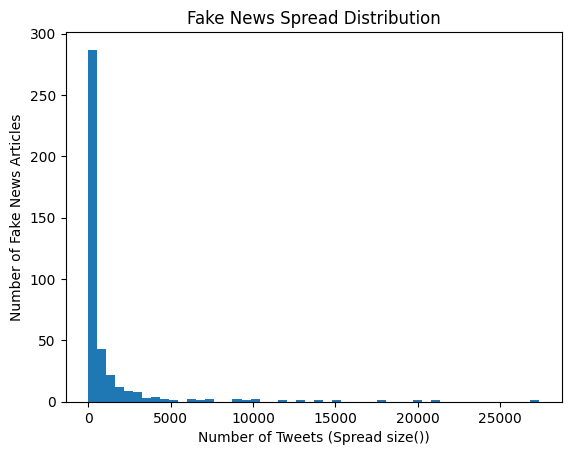

In [19]:
plt.hist(df[df["label"]==0]["num_tweets"], bins=50)
plt.xlabel("Number of Tweets (Spread size())")
plt.ylabel("Number of Fake News Articles")
plt.title("Fake News Spread Distribution")
plt.show()

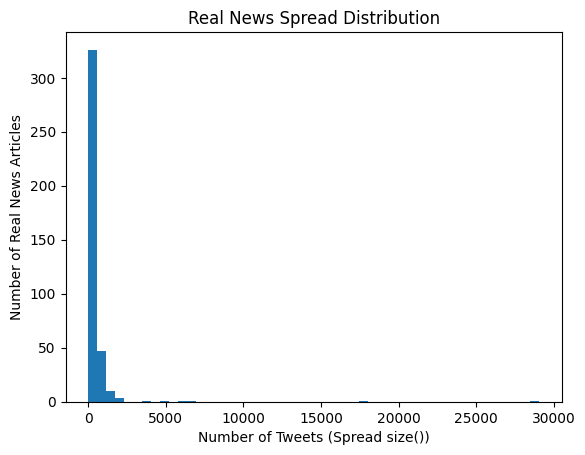

In [20]:
plt.hist(df[df["label"]==1]["num_tweets"], bins=50)
plt.xlabel("Number of Tweets (Spread size())")
plt.ylabel("Number of Real News Articles")
plt.title("Real News Spread Distribution")
plt.show()

Real news propagation exhibits a compact distribution with most articles spreading within a limited tweet range (0–2500), indicating stable dissemination. In contrast, fake news demonstrates a wide propagation range extending up to ~30000 tweets, with a heavy right-tailed distribution. While most fake news spreads moderately (0–6000 tweets), some articles achieve extremely large cascades, indicating bursty and unpredictable virality.

In [21]:
df["log_spread"] = np.log1p(df["num_tweets"])

In [22]:
df["is_viral"] = (df["num_tweets"] > df["num_tweets"].quantile(0.9)).astype(int)

In [23]:
df["spread_category"] = pd.cut(
    df["num_tweets"],
    bins=[0,100,1000,10000,100000],
    labels=[0,1,2,3]
)

In [24]:
df["tweet_density"] = df["num_tweets"] / df["num_tweets"].max()

In [25]:
df["log_spread"] = np.log1p(df["num_tweets"])
df["is_viral"] = (df["num_tweets"] > df["num_tweets"].quantile(0.9)).astype(int)

df["tweet_density"] = df["num_tweets"] / df["num_tweets"].max()

print(df.head())

                id                                              title  \
0  politifact15014  BREAKING: First NFL Team Declares Bankruptcy O...   
1  politifact15156  Court Orders Obama To Pay $400 Million In Rest...   
2  politifact14745  UPDATE: Second Roy Moore Accuser Works For Mic...   
3  politifact14355         Oscar Pistorius Attempts To Commit Suicide   
4  politifact15371        Trump Votes For Death Penalty For Being Gay   

                                           tweet_ids  label  num_tweets  \
0  [937349434668498944, 937379378006282240, 93738...      1         163   
1  [972666281441878016, 972678396575559680, 97282...      1         102   
2  [929405740732870656, 929439450400264192, 92943...      1         220   
3  [886941526458347521, 887011300278194176, 88702...      1          22   
4  [915205698212040704, 915242076681506816, 91524...      1         550   

   log_spread  is_viral spread_category  tweet_density  
0    5.099866         0               1       0.00560

In [26]:
df

,id,title,tweet_ids,label,num_tweets,log_spread,is_viral,spread_category,tweet_density
0,politifact15014,BREAKING: First NFL Team Declares Bankruptcy O...,"[937349434668498944, 937379378006282240, 93738...",1,163,5.099866,0,1,0.005609
1,politifact15156,Court Orders Obama To Pay $400 Million In Rest...,"[972666281441878016, 972678396575559680, 97282...",1,102,4.634729,0,1,0.003510
2,politifact14745,UPDATE: Second Roy Moore Accuser Works For Mic...,"[929405740732870656, 929439450400264192, 92943...",1,220,5.398163,0,1,0.007571
3,politifact14355,Oscar Pistorius Attempts To Commit Suicide,"[886941526458347521, 887011300278194176, 88702...",1,22,3.135494,0,0,0.000757
4,politifact15371,Trump Votes For Death Penalty For Being Gay,"[915205698212040704, 915242076681506816, 91524...",1,550,6.311735,0,1,0.018926
...,...,...,...,...,...,...,...,...,...
1049,politifact6931,The Obameter: Introduce a comprehensive immigr...,"[21096374968, 21096771824, 9413452992876544, 1...",0,137,4.927254,0,1,0.004714
1050,politifact13619,"Trump asking Congress, not Mexico, to pay for ...","[817357495047979008, 817357627566985217, 81735...",0,976,6.884487,0,1,0.033586
1052,politifact329,Change We Can Believe In,"[634287923135909888, 946743411100536832, 94681...",0,182,5.209486,0,1,0.006263
1054,politifact4720,Romneys ProLife Conversion Myth or Reality Jun...,[188871706637647874],0,1,0.693147,0,0,0.000034


In [27]:
features = [
    "num_tweets",
    "log_spread",
    "tweet_density",
    "is_viral",
    "spread_category"
]

X = df[features].copy()
y = df["label"].copy()

In [28]:
X["spread_category"] = X["spread_category"].astype(int)
print(X.dtypes)

num_tweets           int64
log_spread         float64
tweet_density      float64
is_viral             int32
spread_category      int32
dtype: object


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801 entries, 0 to 1055
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   id               801 non-null    object  
 1   title            801 non-null    object  
 2   tweet_ids        801 non-null    object  
 3   label            801 non-null    int64   
 4   num_tweets       801 non-null    int64   
 5   log_spread       801 non-null    float64 
 6   is_viral         801 non-null    int32   
 7   spread_category  801 non-null    category
 8   tweet_density    801 non-null    float64 
dtypes: category(1), float64(2), int32(1), int64(2), object(3)
memory usage: 54.2+ KB


In [30]:
import pickle
import numpy as np
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [31]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_text = tfidf.fit_transform(df["title"])

In [32]:
spread_features = df[[
    "num_tweets",
    "log_spread",
    "tweet_density",
    "is_viral",
    "spread_category"
]].values

In [33]:
X_final = hstack([X_text, spread_features])
y = df["label"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7701863354037267
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        82
           1       0.78      0.73      0.76        79

    accuracy                           0.77       161
   macro avg       0.77      0.77      0.77       161
weighted avg       0.77      0.77      0.77       161



In [37]:
importances = rf.feature_importances_

spread_importance = importances[-5:]

spread_feature_names = [
    "num_tweets",
    "log_spread",
    "tweet_density",
    "is_viral",
    "spread_category"
]

for name, imp in zip(spread_feature_names, spread_importance):
    print(name, imp)

num_tweets 0.03780260069606934
log_spread 0.03701734587778928
tweet_density 0.04096356086918741
is_viral 0.008901919435578741
spread_category 0.013568419262867136


In [38]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_final.fit(X_final, y)

with open("fake_news_model.pkl", "wb") as f:
    pickle.dump(rf_final, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model and TF-IDF saved successfully.")

Model and TF-IDF saved successfully.
